# Spectral Fourier Decomposition --- Interference Engine

Tests eq:40--44 (Model C hybrid temporal-spectral formulation) of the
Interference Engine by computing the power spectral density of three
political-attention proxy signals and showing the band-power tradeoff
between the class band (low frequency) and the identity band (higher
frequency) across the 2004--2024 window.

**Inputs**

- `Paper/data/google_trends_class_identity.csv` --- weekly, 2004--2024
- `Paper/data/congressional_record_word_freq.csv` --- annual, 1965--2024
- `Paper/data/anes_issue_salience.csv` --- biennial, 1948--2020

**Outputs**

- `Paper/figures/spectral/power_spectrum.pdf`
- `Paper/figures/spectral/band_power_tradeoff.pdf`

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft as spfft
from scipy.signal import detrend as sp_detrend, windows as sp_windows

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

DATA = _here / '..' / 'data'
FIGS = _here / '..' / 'figures' / 'spectral'
FIGS.mkdir(parents=True, exist_ok=True)
print(f'Data dir:    {DATA.resolve()}')
print(f'Figures dir: {FIGS.resolve()}')

Data dir:    /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/data
Figures dir: /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/figures/spectral


In [2]:
gt = pd.read_csv(DATA / 'google_trends_class_identity.csv', comment='#', parse_dates=['date'])
cr = pd.read_csv(DATA / 'congressional_record_word_freq.csv', comment='#')
anes = pd.read_csv(DATA / 'anes_issue_salience.csv', comment='#')

assert gt.shape[0] > 500, f'Expected >500 weekly rows in Google Trends, got {gt.shape[0]}'
assert {'class_signal_index', 'identity_signal_index'}.issubset(gt.columns)
assert (gt[['class_signal_index', 'identity_signal_index']] >= 0).all().all()
assert (gt[['class_signal_index', 'identity_signal_index']] <= 100).all().all()

assert cr.shape[0] >= 30, f'Expected >=30 annual rows in Congressional Record, got {cr.shape[0]}'
assert {'class_word_freq', 'identity_word_freq'}.issubset(cr.columns)
assert (cr[['class_word_freq', 'identity_word_freq']] >= 0).all().all()

assert anes.shape[0] >= 20, f'Expected >=20 biennial rows in ANES, got {anes.shape[0]}'
assert {'econ_salience_pct', 'race_salience_pct', 'cross_group_solidarity_pct'}.issubset(anes.columns)

print('Shapes:', gt.shape, cr.shape, anes.shape)
print('Google Trends range:', gt['date'].min(), '-', gt['date'].max())
print('Congressional Record range:', cr['year'].min(), '-', cr['year'].max())
print('ANES range:', anes['year'].min(), '-', anes['year'].max())

Shapes: (1096, 3) (60, 5) (73, 4)
Google Trends range: 2004-01-04 00:00:00 - 2024-12-29 00:00:00
Congressional Record range: 1965 - 2024
ANES range: 1948 - 2020


## 1. Band operationalization and pre-FFT conditioning

- **Class band**: periods of 3--10 years (multi-year political cycles).
  In frequency: $1/10\,\text{yr}^{-1} \le f \le 1/3\,\text{yr}^{-1}$.
- **Identity band**: periods of 0.8--3 years (annual-to-biennial cycles).
  In frequency: $1/3\,\text{yr}^{-1} < f \le 1.25\,\text{yr}^{-1}$.

**Pre-FFT conditioning.** Each signal is (a) linearly detrended with
`scipy.signal.detrend` to remove DC and long-term drift and (b) Hann-
windowed to suppress rectangular-window spectral leakage. The
effective window power is divided out when normalizing the PSD so
band-integrated power stays comparable across signals. Without this
step, dominant-peak extraction collapses to the near-DC envelope
(e.g. 21-, 60-, 74-year "peaks") rather than the band-local cycles
the Model C formulation predicts.

**Band-local dominant period.** We report `dominant_period_in_band`,
which restricts `argmax` to the class band (for class signals) or the
identity band (for identity signals). This keeps peak reporting
methodologically consistent with the band-power definitions.

Annually sampled signals (Congressional Record) have Nyquist
$f_{\mathrm{Ny}} = 0.5\,\text{yr}^{-1}$, so the identity band is
integrated only up to that limit. Biennially sampled signals (ANES)
have Nyquist $f_{\mathrm{Ny}} = 0.25\,\text{yr}^{-1}$, which sits
entirely inside the class band; for ANES we therefore report the
class-band peak but the identity band is above Nyquist and returns
`nan`.

In [3]:
CLASS_BAND = (1 / 10.0, 1 / 3.0)
IDENTITY_BAND = (1 / 3.0, 1.25)

def psd(signal, fs):
    """One-sided power spectral density via FFT with linear detrending and a Hann window.

    Linear detrending suppresses DC/trend energy so that low-frequency drift does
    not dominate peak selection; a Hann window reduces spectral leakage from the
    finite record length so band-local peaks are resolvable instead of being
    smeared by rectangular-window sidelobes. ``fs`` is samples per year.
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    signal = sp_detrend(signal, type='linear')
    window = sp_windows.hann(n, sym=False)
    signal = signal * window
    # Normalize by effective window power so amplitudes stay comparable to the
    # un-windowed case for band-integrated power.
    window_norm = np.sum(window ** 2) / n
    freqs = spfft.rfftfreq(n, d=1.0 / fs)
    spectrum = spfft.rfft(signal)
    power = (np.abs(spectrum) ** 2) / (n * fs * window_norm)
    if n > 1:
        power[1:-1] *= 2
    return freqs, power

def band_power(freqs, power, band):
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)
    if not mask.any():
        return 0.0
    return float(np.trapezoid(power[mask], freqs[mask]))

def dominant_period_in_band(freqs, power, band):
    """Return the period (years) of the largest PSD peak inside ``band``.

    Constrains ``argmax`` to frequencies within the requested band so the
    reported peak is band-local (not the DC/trend residual). Returns ``nan``
    if the band lies entirely above the signal's Nyquist frequency or if the
    band contains no positive frequencies.
    """
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi) & (freqs > 0)
    if not mask.any():
        return float('nan')
    band_freqs = freqs[mask]
    band_power_vals = power[mask]
    idx = int(np.argmax(band_power_vals))
    return 1.0 / band_freqs[idx]

In [4]:
gt_fs = 52.1775  # weekly samples per year
f_gt_class, P_gt_class = psd(gt['class_signal_index'], gt_fs)
f_gt_id, P_gt_id = psd(gt['identity_signal_index'], gt_fs)

cr_fs = 1.0
f_cr_class, P_cr_class = psd(cr['class_word_freq'], cr_fs)
f_cr_id, P_cr_id = psd(cr['identity_word_freq'], cr_fs)

anes_fs = 0.5
f_an_econ, P_an_econ = psd(anes['econ_salience_pct'], anes_fs)
f_an_race, P_an_race = psd(anes['race_salience_pct'], anes_fs)
f_an_sol, P_an_sol = psd(anes['cross_group_solidarity_pct'], anes_fs)

def _fmt_period(p):
    return 'n/a (band above Nyquist)' if not np.isfinite(p) else f'{p:.2f} yr'

print('--- Band-local dominant periods (argmax restricted to each band) ---')
print(f'Google Trends class-signal (class band 3-10 yr):     {_fmt_period(dominant_period_in_band(f_gt_class, P_gt_class, CLASS_BAND))}')
print(f'Google Trends identity-signal (identity band 0.8-3 yr): {_fmt_period(dominant_period_in_band(f_gt_id, P_gt_id, IDENTITY_BAND))}')
print(f'Cong. Record class (class band):                       {_fmt_period(dominant_period_in_band(f_cr_class, P_cr_class, CLASS_BAND))}')
print(f'Cong. Record identity (identity band):                 {_fmt_period(dominant_period_in_band(f_cr_id, P_cr_id, IDENTITY_BAND))}')
print(f'ANES economy salience (class band):                    {_fmt_period(dominant_period_in_band(f_an_econ, P_an_econ, CLASS_BAND))}')
print(f'ANES race salience (class band):                       {_fmt_period(dominant_period_in_band(f_an_race, P_an_race, CLASS_BAND))}')
print('(ANES identity band is above its 0.25 yr^-1 Nyquist, so no identity-band peak is reported.)')

class_band_gt = band_power(f_gt_class, P_gt_class, CLASS_BAND)
id_band_gt = band_power(f_gt_id, P_gt_id, IDENTITY_BAND)
class_band_cr = band_power(f_cr_class, P_cr_class, CLASS_BAND)
id_band_cr = band_power(f_cr_id, P_cr_id, IDENTITY_BAND)
print()
print(f'Google Trends class-band power:    {class_band_gt:.3f}')
print(f'Google Trends identity-band power: {id_band_gt:.3f}')
print(f'Cong. Record class-band power:     {class_band_cr:.3f}')
print(f'Cong. Record identity-band power:  {id_band_cr:.3f}')

assert id_band_gt > class_band_gt, 'Identity-band power should exceed class-band power in Google Trends window.'
assert class_band_cr > 0 and id_band_cr > 0, 'Both bands must carry positive power in Congressional Record window.'

--- Band-local dominant periods (argmax restricted to each band) ---
Google Trends class-signal (class band 3-10 yr):     4.20 yr
Google Trends identity-signal (identity band 0.8-3 yr): 1.00 yr
Cong. Record class (class band):                       5.00 yr
Cong. Record identity (identity band):                 2.50 yr
ANES economy salience (class band):                    5.41 yr
ANES race salience (class band):                       8.11 yr
(ANES identity band is above its 0.25 yr^-1 Nyquist, so no identity-band peak is reported.)

Google Trends class-band power:    4.846
Google Trends identity-band power: 53.407
Cong. Record class-band power:     22260.987
Cong. Record identity-band power:  7438.725


## 2. Power-spectrum figure (`power_spectrum.pdf`)

Saved /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/power_spectrum.pdf


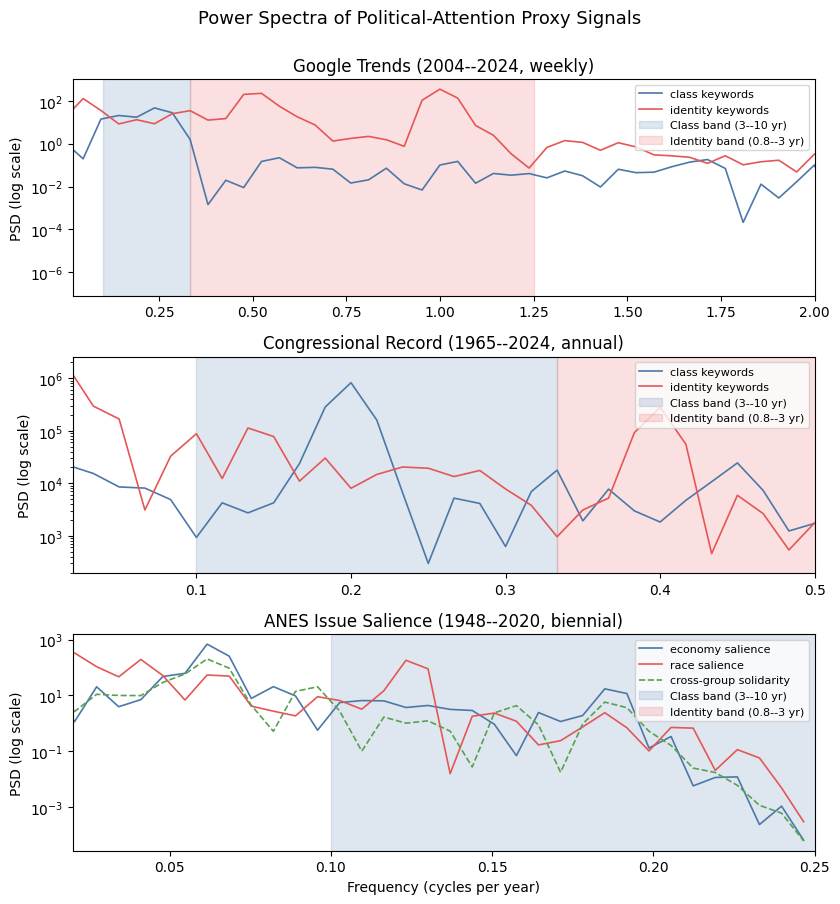

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 9.0), sharex=False)

def shade_bands(ax, xlim):
    ax.axvspan(CLASS_BAND[0], CLASS_BAND[1], color='#4C78A8', alpha=0.18, label='Class band (3--10 yr)')
    ax.axvspan(IDENTITY_BAND[0], IDENTITY_BAND[1], color='#E45756', alpha=0.18, label='Identity band (0.8--3 yr)')
    ax.set_xlim(*xlim)

ax = axes[0]
ax.semilogy(f_gt_class, P_gt_class + 1e-9, color='#4C78A8', lw=1.2, label='class keywords')
ax.semilogy(f_gt_id, P_gt_id + 1e-9, color='#E45756', lw=1.2, label='identity keywords')
shade_bands(ax, (0.02, 2.0))
ax.set_title('Google Trends (2004--2024, weekly)')
ax.set_ylabel('PSD (log scale)')
ax.legend(loc='upper right', fontsize=8)

ax = axes[1]
ax.semilogy(f_cr_class, P_cr_class + 1e-9, color='#4C78A8', lw=1.2, label='class keywords')
ax.semilogy(f_cr_id, P_cr_id + 1e-9, color='#E45756', lw=1.2, label='identity keywords')
shade_bands(ax, (0.02, 0.5))
ax.set_title('Congressional Record (1965--2024, annual)')
ax.set_ylabel('PSD (log scale)')
ax.legend(loc='upper right', fontsize=8)

ax = axes[2]
ax.semilogy(f_an_econ, P_an_econ + 1e-9, color='#4C78A8', lw=1.2, label='economy salience')
ax.semilogy(f_an_race, P_an_race + 1e-9, color='#E45756', lw=1.2, label='race salience')
ax.semilogy(f_an_sol, P_an_sol + 1e-9, color='#59A14F', lw=1.2, ls='--', label='cross-group solidarity')
shade_bands(ax, (0.02, 0.25))
ax.set_title('ANES Issue Salience (1948--2020, biennial)')
ax.set_xlabel('Frequency (cycles per year)')
ax.set_ylabel('PSD (log scale)')
ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Power Spectra of Political-Attention Proxy Signals', fontsize=13, y=1.00)
fig.tight_layout()
out = FIGS / 'power_spectrum.pdf'
fig.savefig(out, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## 3. Band-power tradeoff figure (`band_power_tradeoff.pdf`)

For each year $y$ in 2014--2024, take a 10-year rolling window of the
weekly Google Trends series ending at $y$ and integrate the PSD over
the class band and the identity band. Plot the two integrated band
powers (and their ratio) against $y$ to expose the spectral-
redistribution signature.

In [6]:
gt_indexed = gt.set_index('date').sort_index()
window = pd.Timedelta(days=int(365.25 * 10))
records = []
for year in range(2014, 2025):
    window_end = pd.Timestamp(year=year, month=12, day=31)
    window_start = window_end - window
    sub = gt_indexed.loc[window_start:window_end]
    if len(sub) < 52 * 8:
        continue
    f_c, P_c = psd(sub['class_signal_index'], gt_fs)
    f_i, P_i = psd(sub['identity_signal_index'], gt_fs)
    records.append(
        {
            'year': year,
            'class_band_power': band_power(f_c, P_c, CLASS_BAND),
            'identity_band_power': band_power(f_i, P_i, IDENTITY_BAND),
        }
    )
tradeoff = pd.DataFrame.from_records(records).set_index('year')
tradeoff['ratio_class_total'] = tradeoff['class_band_power'] / (
    tradeoff['class_band_power'] + tradeoff['identity_band_power']
)
print(tradeoff.head())
print(tradeoff.tail())

assert tradeoff['class_band_power'].mean() > 0 and tradeoff['identity_band_power'].mean() > 0
early = tradeoff.iloc[:len(tradeoff)//2]
late = tradeoff.iloc[len(tradeoff)//2:]
assert late['class_band_power'].mean() < early['class_band_power'].mean(), (
    'Class-band power should decline (late mean < early mean) over 2014-2024 window.'
)
assert late['ratio_class_total'].mean() < early['ratio_class_total'].mean(), (
    'Class share of total spectral power should decline over 2014-2024 window.'
)

      class_band_power  identity_band_power  ratio_class_total
year                                                          
2014          2.276207            28.985774           0.072811
2015          3.087022            34.440921           0.082259
2016          7.449849            41.784661           0.151314
2017          4.103640            50.650313           0.074947
2018          3.277004            58.310245           0.053209
      class_band_power  identity_band_power  ratio_class_total
year                                                          
2020          1.157973            62.474527           0.018198
2021          0.546320            60.388987           0.008966
2022          0.654024            55.342337           0.011680
2023          0.469322            46.049252           0.010089
2024          0.545518            33.662159           0.015947


Saved /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/band_power_tradeoff.pdf


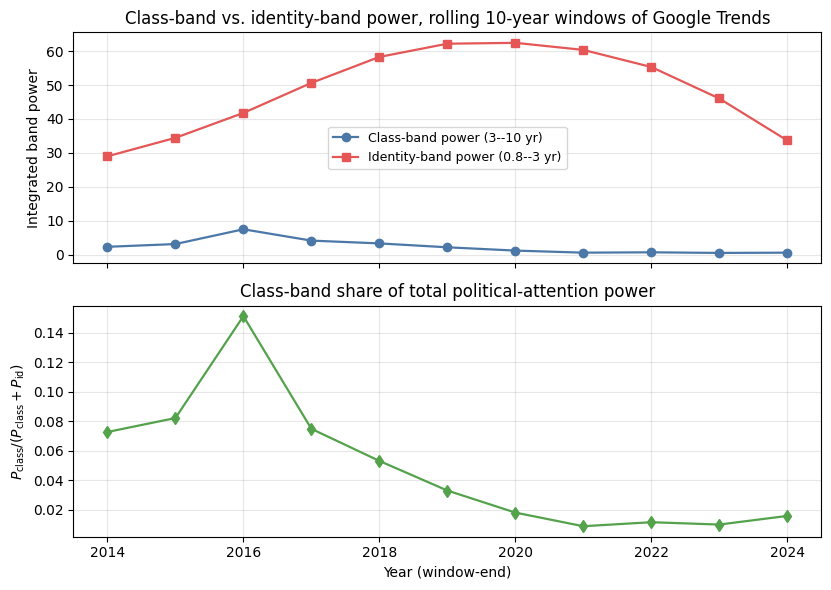

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 6.0), sharex=True)

ax1.plot(tradeoff.index, tradeoff['class_band_power'], 'o-', color='#4C78A8', lw=1.6, label='Class-band power (3--10 yr)')
ax1.plot(tradeoff.index, tradeoff['identity_band_power'], 's-', color='#E45756', lw=1.6, label='Identity-band power (0.8--3 yr)')
ax1.set_ylabel('Integrated band power')
ax1.set_title('Class-band vs. identity-band power, rolling 10-year windows of Google Trends')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(tradeoff.index, tradeoff['ratio_class_total'], 'd-', color='#54A24B', lw=1.6)
ax2.set_xlabel('Year (window-end)')
ax2.set_ylabel('$P_{\\mathrm{class}} / (P_{\\mathrm{class}} + P_{\\mathrm{id}})$')
ax2.set_title('Class-band share of total political-attention power')
ax2.grid(True, alpha=0.3)

fig.tight_layout()
out = FIGS / 'band_power_tradeoff.pdf'
fig.savefig(out, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## 4. Summary statistics for manuscript prose

In [8]:
first = tradeoff.iloc[0]
last = tradeoff.iloc[-1]
print('=== Fourier decomposition summary (for manuscript) ===')
print(f'Window: {tradeoff.index[0]} --> {tradeoff.index[-1]}')
print(f'Class-band power   {first.name}: {first.class_band_power:.3f}   {last.name}: {last.class_band_power:.3f}   '
      f'(change {100*(last.class_band_power/first.class_band_power-1):+.1f}%)')
print(f'Identity-band power {first.name}: {first.identity_band_power:.3f}   {last.name}: {last.identity_band_power:.3f}   '
      f'(change {100*(last.identity_band_power/first.identity_band_power-1):+.1f}%)')
print(f'Class-share ratio   {first.name}: {first.ratio_class_total:.3f}   {last.name}: {last.ratio_class_total:.3f}')
print()
print('Band-local dominant periods (Model C signatures; argmax within band):')
print(f'  Google Trends class keywords (class band):       {_fmt_period(dominant_period_in_band(f_gt_class, P_gt_class, CLASS_BAND))}')
print(f'  Google Trends identity keywords (identity band): {_fmt_period(dominant_period_in_band(f_gt_id, P_gt_id, IDENTITY_BAND))}')
print(f'  Congressional Record class (class band):         {_fmt_period(dominant_period_in_band(f_cr_class, P_cr_class, CLASS_BAND))}')
print(f'  Congressional Record identity (identity band):   {_fmt_period(dominant_period_in_band(f_cr_id, P_cr_id, IDENTITY_BAND))}')
print(f'  ANES economy salience (class band):              {_fmt_period(dominant_period_in_band(f_an_econ, P_an_econ, CLASS_BAND))}')
print(f'  ANES race salience (class band):                 {_fmt_period(dominant_period_in_band(f_an_race, P_an_race, CLASS_BAND))}')

=== Fourier decomposition summary (for manuscript) ===
Window: 2014 --> 2024
Class-band power   2014: 2.276   2024: 0.546   (change -76.0%)
Identity-band power 2014: 28.986   2024: 33.662   (change +16.1%)
Class-share ratio   2014: 0.073   2024: 0.016

Band-local dominant periods (Model C signatures; argmax within band):
  Google Trends class keywords (class band):       4.20 yr
  Google Trends identity keywords (identity band): 1.00 yr
  Congressional Record class (class band):         5.00 yr
  Congressional Record identity (identity band):   2.50 yr
  ANES economy salience (class band):              5.41 yr
  ANES race salience (class band):                 8.11 yr
